# Synergy prediction using bulk RNA-seq data

## Data loading

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np

Load the time-matched transcriptional scores, synergie scores, and metadata.

In [ ]:
from src.dge_data import (
    simple_interaction_score,
    eob_score,
    hsa_score,
    get_all_synergy_data
)

# Local data directories
l2fc_dir = "C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/dge_timezero"
cfu_dir = "C:/Users/eddyk/OneDrive/Documents/vanopijnen_lab/all_cfus"

# Bliss
bliss_df = get_all_synergy_data(
    l2fc_dir = l2fc_dir,
    cfu_dir = cfu_dir,
    interaction_score_method = simple_interaction_score,
    synergy_score_method = eob_score,
    time_matched = True
)

# HSA
hsa_df = get_all_synergy_data(
    l2fc_dir = l2fc_dir,
    cfu_dir = cfu_dir,
    interaction_score_method = simple_interaction_score,
    synergy_score_method = hsa_score,
    time_matched = True
)

## Data cleaning

In [1]:
# Look at which genes have NA values

# Look at which features are most correlated with synergy?

# Do some sort of recursive feature selection

In [ ]:
import missingno

In [9]:
np.sum([hsa_df[col].isna().any() for col in hsa_df.columns])

np.int64(108)

In [15]:
hsa_df.isna().sum().sum()

np.int64(4860)

## Training model

ElasticNet predictions on evenly split drug combinations.

In [ ]:
from src.split import combination_stratified_split

strat_splits = combination_stratified_split(bliss_df)

# One example train test split
split1 = strat_splits[0]

train_df = bliss_df[split1[0]]
test_df = bliss_df[split1[1]]


X_train = train_df.iloc[:, train_df.columns.str.contains("SP")]
y_train 

X_test_= 
y_test = 



ElasticNet predictions on held out combinations.

In [ ]:
from src.split import combination_held_out_split

ElasticNet predictions on held out timepoints.

In [ ]:
from src.split import timepoint_held_out_split

Implement.

0.49328622983598025


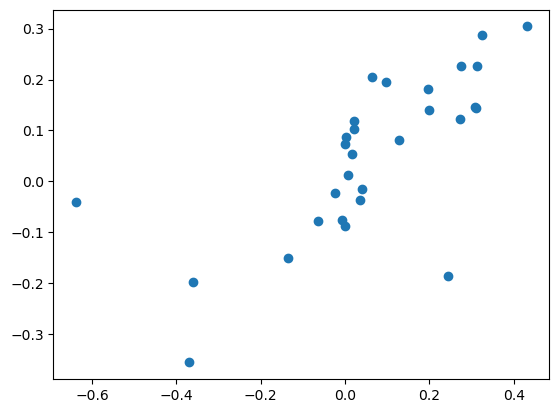

In [ ]:


X = hsa_df.iloc[:, bliss_df.columns.str.contains("SP")].dropna(axis = 1) # remove NA features
y = hsa_df["synergy_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 120)

model = ElasticNetCV()

model.fit(X_train, y_train)

preds = model.predict(X_test)

score = r2_score(y_test, preds)
print(score)

plt.scatter(y_test, preds)